In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset("taxis")

print(df.head())


               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [ ]:
# Check missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Impute categorical columns using mode
categorical_cols = ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# check if any missing values remain
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values per column:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Missing values after imputation:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


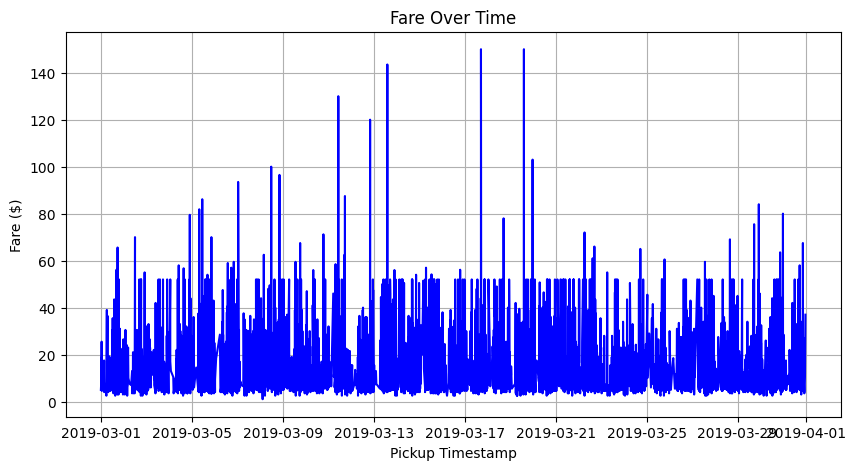

In [ ]:
# Line Chart
# Convert the pickup column to datetime format
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort data by pickup time to make the line chart linear over time
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(10, 5))
plt.plot(df_sorted['pickup'], df_sorted['fare'], color='blue')
plt.title('Fare Over Time')
plt.xlabel('Pickup Timestamp')
plt.ylabel('Fare ($)')
plt.grid(True)
plt.show()


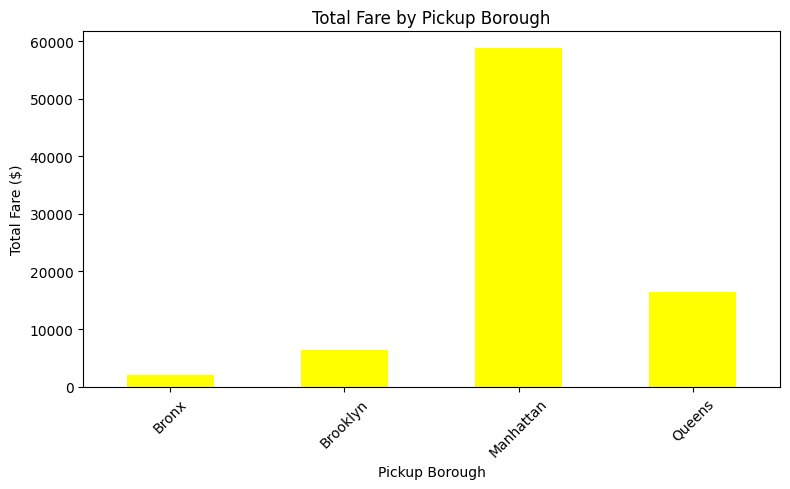

In [8]:
# Bar Charts
# Group data by borough and sum up the fares
borough_fare = df.groupby('pickup_borough')['fare'].sum()

# Plot the bar chart
borough_fare.plot(kind='bar', figsize=(8, 5), color='yellow')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


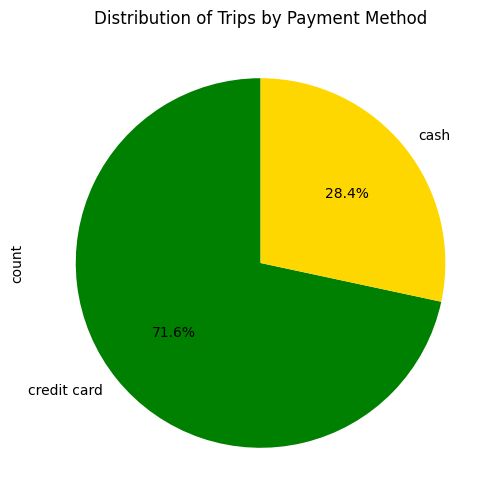

In [ ]:
# Pie Chart
# Count trips for each payment method
payment_counts = df['payment'].value_counts()

# Plot the pie chart
payment_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), startangle=90, colors=['green', 'gold'])
plt.title('Distribution of Trips by Payment Method')

plt.show()


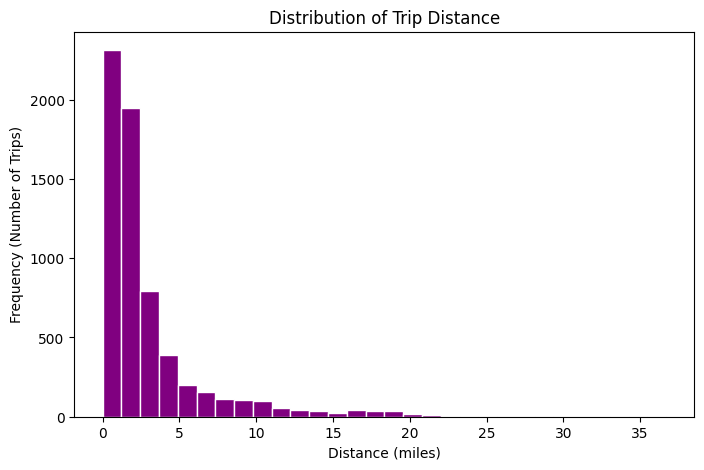

In [ ]:
# histogram
plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=30, color='purple', edgecolor='white')
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency (Number of Trips)')
plt.show()


<Figure size 1000x600 with 0 Axes>

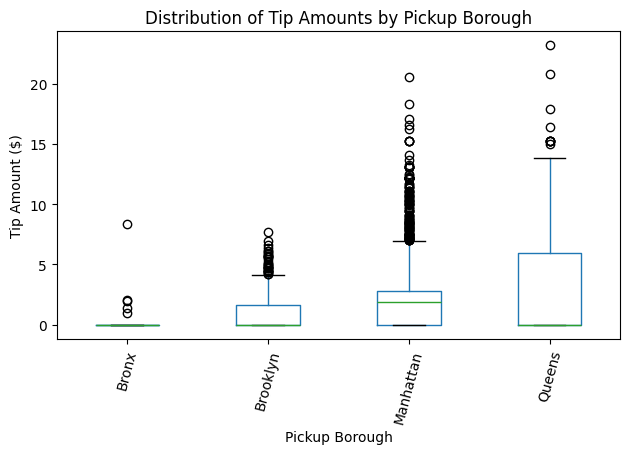

In [10]:
plt.figure(figsize=(10, 6))
df.boxplot(column='tip', by='pickup_borough', grid=False)
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount ($)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1591/2697122240.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough', palette='Set2')


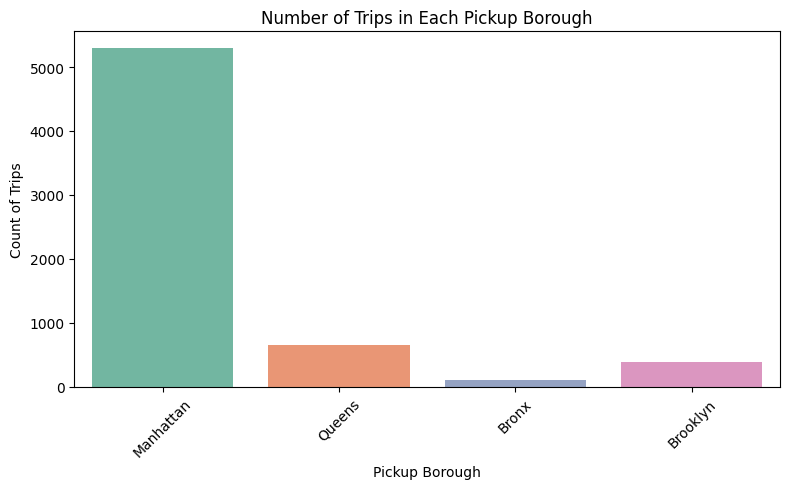

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough', palette='Set2')
plt.title('Number of Trips in Each Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


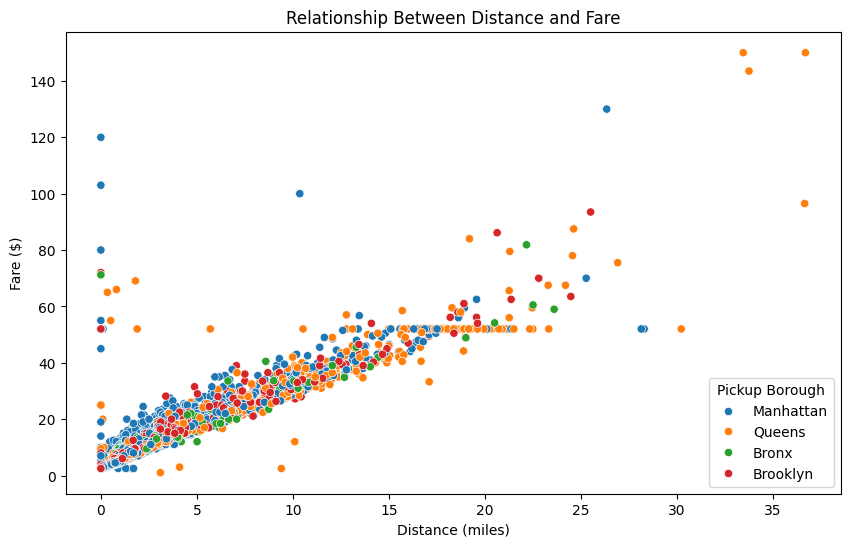

In [ ]:
#scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')
plt.title('Relationship Between Distance and Fare')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare ($)')
plt.legend(title='Pickup Borough')
plt.show()


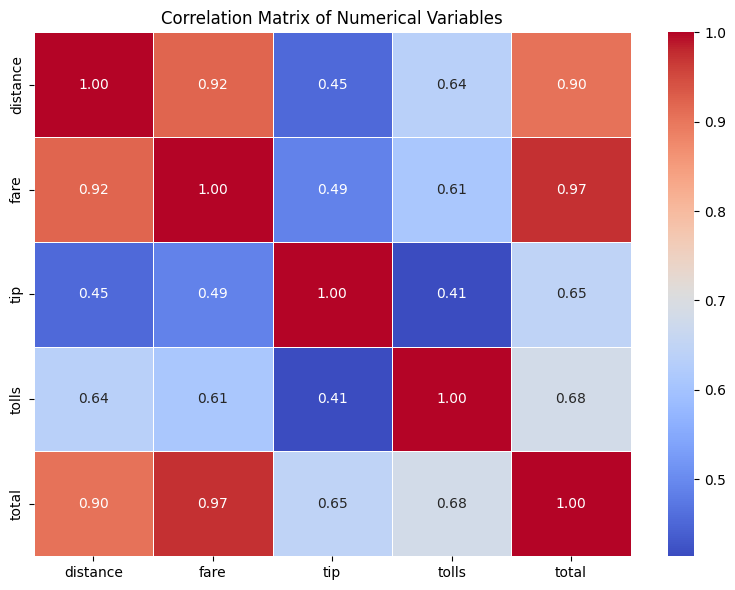

In [ ]:
# heatmap
plt.figure(figsize=(8, 6))
# Select only requested numerical variables
numerical_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
corr_matrix = df[numerical_cols].corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


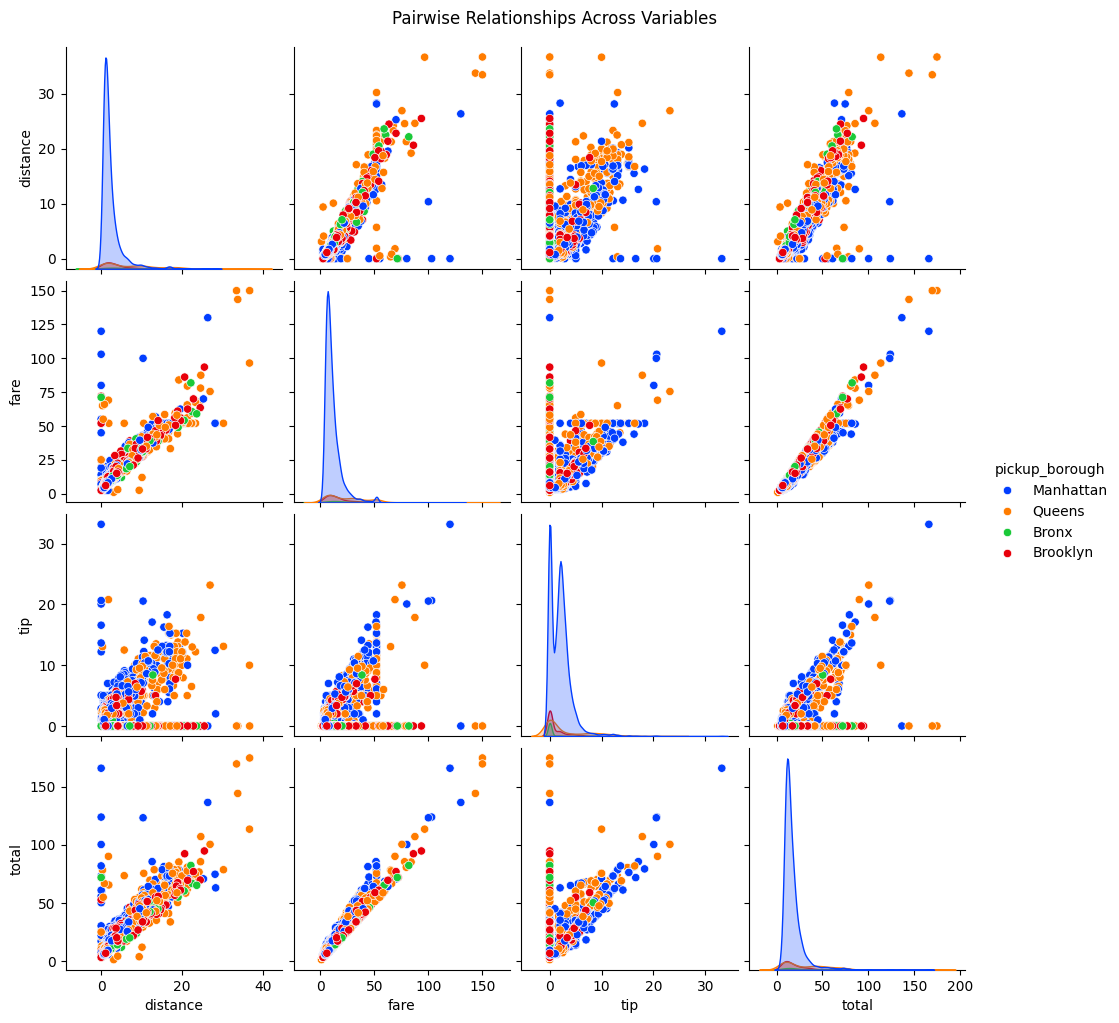

In [ ]:
# pair plot

sns.pairplot(data=df, vars=['distance', 'fare', 'tip', 'total'], hue='pickup_borough', palette='bright')
plt.suptitle('Pairwise Relationships Across Variables', y=1.02)
plt.show()


/tmp/ipykernel_1591/1769269405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='payment', y='fare', palette='Pastel1')


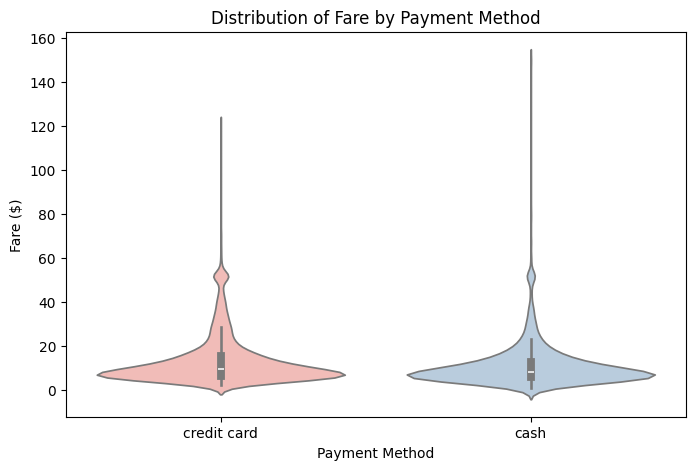

In [ ]:
# violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='payment', y='fare', palette='Pastel1')
plt.title('Distribution of Fare by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.show()
